In [70]:
import os
import pandas as pd
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from sklearn.model_selection import train_test_split
import numpy as np

In [96]:
# ========================= PATHS =========================
# 1. Get the absolute path of the folder containing this notebook
NOTEBOOK_DIR = os.path.abspath("")

# 2. Build the absolute path to your dataset folder
BASE_DIR = os.path.abspath(os.path.join(NOTEBOOK_DIR, "..", "data_set_generator_for_cnns_only", "data_set"))

TRAIN_IMG_DIR = os.path.join(BASE_DIR, "train")
VALID_IMG_DIR = os.path.join(BASE_DIR, "valid")
TEST_IMG_DIR  = os.path.join(BASE_DIR, "test")

TRAIN_CSV = os.path.join(BASE_DIR, "train.csv")
VALID_CSV = os.path.join(BASE_DIR, "valid.csv")
TEST_CSV  = os.path.join(BASE_DIR, "test.csv")

# Quick sanity check printouts
print("Checking paths...")
print(f"Train CSV exists: {os.path.exists(TRAIN_CSV)}")
print(f"Train Image Directory exists: {os.path.exists(TRAIN_IMG_DIR)}")
print(f"Valid CSV exists: {os.path.exists(VALID_CSV)}")
print(f"Valid Image Directory exists: {os.path.exists(VALID_IMG_DIR)}")
print(f"Test CSV exists: {os.path.exists(TEST_CSV)}")
print(f"Test Image Directory exists: {os.path.exists(TEST_IMG_DIR)}")

Checking paths...
Train CSV exists: True
Train Image Directory exists: True
Valid CSV exists: True
Valid Image Directory exists: True
Test CSV exists: True
Test Image Directory exists: True


In [72]:

# ========================= CONFIG =========================
IMAGE_HEIGHT = 40
IMAGE_WIDTH = 160
BATCH_SIZE = 16
EPOCHS = 50


In [97]:
# ====================== PREPROCESS ======================\n",
def preprocess_image(image_path):
    # Remove the broad try-except; let TensorFlow handle paths natively
    img = tf.io.read_file(image_path)
    img = tf.image.decode_png(img, channels=1)
    img = tf.image.resize(img, [IMAGE_HEIGHT, IMAGE_WIDTH])
    return tf.cast(img, tf.float32) / 255.0


# ====================== PARSE DATA ======================\n",
def parse_data(row, image_dir):
    # Ensure correct string formatting for file paths
    img_path = tf.strings.join([image_dir, row['image']], separator=os.sep)
    image = preprocess_image(img_path)
    
    # 1. Cast label to integer
    label_int = tf.cast(row['label'], tf.int32)
    
    # 2. Extract digits using basic base-10 math (No py_function needed)
    # Replaces string padding/zfill logic dynamically
    d1 = (label_int // 10000) % 10
    d2 = (label_int // 1000) % 10
    d3 = (label_int // 100) % 10
    d4 = (label_int // 10) % 10
    d5 = label_int % 10
    
    # Explicitly set standard scalar shapes to be absolutely safe
    for d in [d1, d2, d3, d4, d5]:
        d.set_shape([])

    return image, {
        'digit1': d1,
        'digit2': d2,
        'digit3': d3,
        'digit4': d4,
        'digit5': d5
    }


def create_dataset(df, image_dir, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices(dict(df))
    
    if shuffle:
        ds = ds.shuffle(buffer_size=512)   # Fixed number instead of len(df)
    
    ds = ds.map(lambda row: parse_data(row, image_dir), 
                num_parallel_calls=tf.data.AUTOTUNE)
    
    ds = ds.batch(BATCH_SIZE)
    ds = ds.prefetch(tf.data.AUTOTUNE)
    return ds

In [98]:
# ========================= LOAD DATA (FAIL-SAFE) =========================
print("Loading datasets safely...")
df_train = pd.read_csv(TRAIN_CSV)
df_valid = pd.read_csv(VALID_CSV)
df_test  = pd.read_csv(TEST_CSV)

# 1. Filter out training rows where the image file is physically missing from disk
train_mask = df_train['image'].apply(lambda x: os.path.exists(os.path.join(TRAIN_IMG_DIR, str(x))))
missing_train = len(df_train) - train_mask.sum()
if missing_train > 0:
    print(f"⚠️ Warning: {missing_train} rows in train.csv don't have matching files on disk. Skipping them.")
df_train = df_train[train_mask]

# 2. Filter out validation rows where the image file is physically missing from disk
valid_mask = df_valid['image'].apply(lambda x: os.path.exists(os.path.join(VALID_IMG_DIR, str(x))))
missing_valid = len(df_valid) - valid_mask.sum()
if missing_valid > 0:
    print(f"⚠️ Warning: {missing_valid} rows in valid.csv don't have matching files on disk. Skipping them.")
df_valid = df_valid[valid_mask]
test_mask = df_test['image'].apply(lambda x: os.path.exists(os.path.join(TEST_IMG_DIR, str(x))))
missing_test = len(df_test) - test_mask.sum()


# 3. Create datasets cleanly from the verified rows
train_ds = create_dataset(df_train, TRAIN_IMG_DIR, shuffle=True)
val_ds   = create_dataset(df_valid, VALID_IMG_DIR, shuffle=False)
test_ds  = create_dataset(df_test, TEST_IMG_DIR, shuffle=False)

print(f"\nFinal Ready Samples -> Train: {len(df_train)} | Val: {len(df_valid)} | Test: {len(df_test)}")

Loading datasets safely...

Final Ready Samples -> Train: 1270 | Val: 173 | Test: 212


In [99]:

# ========================= MODEL =========================
def build_model():
    inputs = layers.Input(shape=(IMAGE_HEIGHT, IMAGE_WIDTH, 1), name="input")
    
    x = layers.Conv2D(32, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)
    
    x = layers.Conv2D(64, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(128, 3, padding='same', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=(2,1), strides=(2,1))(x)
    x = layers.Dropout(0.4)(x)
    
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(x)
    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.5)(x)
    
    outputs = {
        f'digit{i}': layers.Dense(10, activation='softmax', name=f'digit{i}')(x)
        for i in range(1, 6)
    }
    
    model = models.Model(inputs, outputs)
    return model

model = build_model()
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input (InputLayer)  │ (None, 40, 160,   │          0 │ -                 │
│                     │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_27 (Conv2D)  │ (None, 40, 160,   │        320 │ input[0][0]       │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 40, 160,   │        128 │ conv2d_27[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_27       │ (None, 40, 160,   │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_27    │ (None, 20, 80,    │          0 │ activation_27[0]… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_36          │ (None, 20, 80,    │          0 │ max_pooling2d_27… │
│ (Dropout)           │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_28 (Conv2D)  │ (None, 20, 80,    │     18,496 │ dropout_36[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 20, 80,    │        256 │ conv2d_28[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_28       │ (None, 20, 80,    │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_28    │ (None, 10, 40,    │          0 │ activation_28[0]… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_37          │ (None, 10, 40,    │          0 │ max_pooling2d_28… │
│ (Dropout)           │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_29 (Conv2D)  │ (None, 10, 40,    │     73,856 │ dropout_37[0][0]  │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 10, 40,    │        512 │ conv2d_29[0][0]   │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_29       │ (None, 10, 40,    │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_29    │ (None, 5, 40,     │          0 │ activation_29[0]… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_38          │ (None, 5, 40,     │          0 │ max_pooling2d_29… │
│ (Dropout)           │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_9 (Flatten) │ (None, 25600)     │          0 │ dropout_38[0][0]

 Total params: 6,661,298 (25.41 MB)

 Trainable params: 6,660,338 (25.41 MB)

 Non-trainable params: 960 (3.75 KB)

In [85]:
# ========================= TRAINING =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss={f'digit{i}': 'sparse_categorical_crossentropy' for i in range(1,6)},
    metrics={f'digit{i}': 'accuracy' for i in range(1,6)}
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.ModelCheckpoint("best_captcha_model.keras", save_best_only=True, monitor='val_loss', verbose=1)
]

In [86]:
import os
import pandas as pd

def check_dataset_mismatches(csv_path, img_dir, split_name="Dataset"):
    if not os.path.exists(csv_path) or not os.path.exists(img_dir):
        print(f"❌ Error with {split_name}: CSV or Image Directory does not exist.")
        return

    # Load the CSV and get all filenames listed there
    df = pd.read_csv(csv_path)
    csv_filenames = set(df['image'].astype(str).tolist())
    
    # Scan the physical folder for files actually present
    folder_filenames = set(os.listdir(img_dir))
    # Filter out system hidden files (like .DS_Store)
    folder_filenames = {f for f in folder_filenames if not f.startswith('.')}

    print(f"=== {split_name.upper()} SPLIT CHECK ===")
    
    # 1. Listed in CSV but MISSING from the folder
    missing_from_folder = csv_filenames - folder_filenames
    print(f"🔴 Listed in CSV but MISSING from folder: {len(missing_from_folder)}")
    if missing_from_folder:
        print("   Sample missing files (showing up to 5):")
        for f in list(missing_from_folder)[:5]:
            print(f"     - {f}")

    # 2. Present in folder but MISSING from the CSV
    unlisted_in_csv = folder_filenames - csv_filenames
    print(f"🔵 Present in folder but NOT listed in CSV: {len(unlisted_in_csv)}")
    if unlisted_in_csv:
        print("   Sample unlisted files (showing up to 5):")
        for f in list(unlisted_in_csv)[:5]:
            print(f"     - {f}")
            
    print("\n" + "="*40 + "\n")

# Run the check for all three subsets safely
check_dataset_mismatches(TRAIN_CSV, TRAIN_IMG_DIR, "Train")
check_dataset_mismatches(VALID_CSV, VALID_IMG_DIR, "Validation")
check_dataset_mismatches(TEST_CSV, TEST_IMG_DIR, "Test")

=== TRAIN SPLIT CHECK ===
🔴 Listed in CSV but MISSING from folder: 0
🔵 Present in folder but NOT listed in CSV: 0


=== VALIDATION SPLIT CHECK ===
🔴 Listed in CSV but MISSING from folder: 0
🔵 Present in folder but NOT listed in CSV: 0


=== TEST SPLIT CHECK ===
🔴 Listed in CSV but MISSING from folder: 0
🔵 Present in folder but NOT listed in CSV: 0




In [87]:

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks
)


Epoch 1/50


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 416ms/step - digit1_accuracy: 0.2402 - digit1_loss: 2.5756 - digit2_accuracy: 0.3181 - digit2_loss: 2.4267 - digit3_accuracy: 0.2724 - digit3_loss: 2.5621 - digit4_accuracy: 0.1472 - digit4_loss: 2.7459 - digit5_accuracy: 0.0984 - digit5_loss: 2.8866 - loss: 13.2753
Epoch 1: val_loss improved from None to 16.37463, saving model to best_captcha_model.keras

Epoch 1: finished saving model to best_captcha_model.keras
80/80 ━━━━━━━━━━━━━━━━━━━━ 45s 471ms/step - digit1_accuracy: 0.2402 - digit1_loss: 2.5756 - digit2_accuracy: 0.3181 - digit2_loss: 2.4267 - digit3_accuracy: 0.2724 - digit3_loss: 2.5621 - digit4_accuracy: 0.1472 - digit4_loss: 2.7459 - digit5_accuracy: 0.0984 - digit5_loss: 2.8866 - loss: 13.2753 - val_digit1_accuracy: 0.0983 - val_digit1_loss: 2.8560 - val_digit2_accuracy: 0.0520 - val_digit2_loss: 4.7678 - val_digit3_accuracy: 0.0405 - val_digit3_loss: 3.5949 - val_digit4_accuracy: 0.0694 - val_digit4_loss: 2.6872 - val_digit5_accuracy: 0.1156 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step


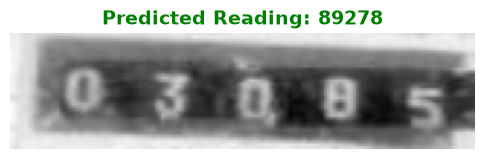

Prediction success! Meter Reading: 89278


In [103]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

# ============================================================
# 1. CONFIGURATION
# ============================================================
# Replace this with the path to the specific image you want to test
IMAGE_PATH = os.path.join(TEST_IMG_DIR, "0642_06408310008_crop_0.png") 

IMAGE_HEIGHT = 40
IMAGE_WIDTH = 160

# ============================================================
# 2. PREPROCESSING FUNCTION (Single Image)
# ============================================================
def prepare_single_image(img_path):
    # Read image in grayscale (matching your channel=1 design)
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Could not load image at {img_path}")
        
    # Resize to the model's expected dimensions
    img_resized = cv2.resize(img, (IMAGE_WIDTH, IMAGE_HEIGHT))
    
    # Normalize pixel values to [0.0, 1.0]
    img_normalized = img_resized.astype(np.float32) / 255.0
    
    # Expand dimensions to match batch format: (Batch_Size, Height, Width, Channels) -> (1, 64, 128, 1)
    img_expanded = np.expand_dims(img_normalized, axis=(0, -1))
    
    return img_resized, img_expanded

# ============================================================
# 3. PREDICT AND DECODE
# ============================================================
# 3. PREDICT AND DECODE
# ============================================================
try:
    # Preprocess the file
    display_img, input_tensor = prepare_single_image(IMAGE_PATH)
    
    # Run prediction (model expects a batch, so we pass our shape-1 batch)
    predictions = model.predict(input_tensor)
    
    # --- AUTO-DETECT DICTIONARY OR LIST OUTPUTS ---
    if isinstance(predictions, dict):
        # Extract predictions via dictionary keys
        pred_d1 = np.argmax(predictions['digit1'][0])
        pred_d2 = np.argmax(predictions['digit2'][0])
        pred_d3 = np.argmax(predictions['digit3'][0])
        pred_d4 = np.argmax(predictions['digit4'][0])
        pred_d5 = np.argmax(predictions['digit5'][0])
    else:
        # Extract predictions via ordered list fallback
        pred_d1 = np.argmax(predictions[0][0])
        pred_d2 = np.argmax(predictions[1][0])
        pred_d3 = np.argmax(predictions[2][0])
        pred_d4 = np.argmax(predictions[3][0])
        pred_d5 = np.argmax(predictions[4][0])
    
    # Combine the individual digits into the final 5-digit string reading
    final_reading = f"{pred_d1}{pred_d2}{pred_d3}{pred_d4}{pred_d5}"
    
    # ============================================================
    # 4. VISUALIZE RESULT
    # ============================================================
    plt.figure(figsize=(6, 3))
    plt.imshow(display_img, cmap='gray')
    plt.title(f"Predicted Reading: {final_reading}", fontsize=14, color='green', fontweight='bold')
    plt.axis('off')
    plt.show()
    
    print(f"Prediction success! Meter Reading: {final_reading}")

except Exception as e:
    print(f"❌ Error during inference: {e}")

In [ ]:

model.save("captcha_model_final.keras")
print("✅ Training completed!")